In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("mpg")

## 1. Carga `auto_mpg.csv` y realiza el primer contacto con el dataset. Reporta dimensiones, 
primeras filas, tipos de datos y define qué representa una fila. 
Pista de trabajo: `shape`, `head()`, `info()` y `dtypes`. 

In [2]:
df.shape

(398, 9)

In [3]:
df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [5]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

## 2. Clasifica `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, 
`model_year`, `origin` y `name`. Identifica qué variables, aunque puedan verse numéricas, 
conviene tratar como categorías o variables temporales. 
Pista de trabajo: El significado de una variable es más importante que su dtype.

In [6]:
import pandas as pd
clasificacion_de_variables=pd.DataFrame({"variable":
                                         [ "mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", "name"],
                                         "Clasificacion":
                                         ["numerica - discreta",
                                          "numerica - discreta",
                                          "numerica - discreta",
                                          "numerica   - discreta",
                                          "numerica - discreta",
                                          "numerica - discreta",
                                          "numerica - continua",
                                          "categorica - nominal",
                                          "categorica - nominal"]
                                         })
clasificacion_de_variables

,variable,Clasificacion
0,mpg,numerica - discreta
1,cylinders,numerica - discreta
2,displacement,numerica - discreta
3,horsepower,numerica - discreta
4,weight,numerica - discreta
5,acceleration,numerica - discreta
6,model_year,numerica - continua
7,origin,categorica - nominal
8,name,categorica - nominal


## 3. Analiza valores faltantes y duplicados exactos. ¿En qué variable faltan datos y qué 
proporción representan?  
Pista de trabajo: Para una correlación puntual puedes trabajar con pares completos sin alterar toda la tabla.

In [7]:
valores_nulos=pd.DataFrame({
    "Numeros_nulos":df.isna().sum(),
    "porcentaje" : df.isna().mean() * 100 ,
     
}).sort_values("porcentaje",ascending=False )
valores_nulos

,Numeros_nulos,porcentaje
horsepower,6,1.507538
mpg,0,0.000000
cylinders,0,0.000000
displacement,0,0.000000
weight,0,0.000000
acceleration,0,0.000000
model_year,0,0.000000
origin,0,0.000000
name,0,0.000000


## 4. Estudia la cardinalidad de `name`. ¿Cuántos nombres distintos hay? ¿Que un nombre 
aparezca varias veces significa que las filas son duplicadas? Compruébalo con ejemplos. 
Pista de trabajo: Un mismo modelo de automóvil puede aparecer en años o configuraciones diferentes. 

In [8]:
cardinalidad_name=df["name"].nunique()
print(cardinalidad_name)

305


In [9]:
contar_nombres = df["name"].value_counts()

print(contar_nombres)

name
ford pinto          6
ford maverick       5
amc matador         5
toyota corolla      5
chevrolet impala    4
                   ..
ford mustang gl     1
vw pickup           1
dodge rampage       1
ford ranger         1
chevy s-10          1
Name: count, Length: 305, dtype: int64


In [10]:
df[df["name"] == "toyota corolla"]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
167,29.0,4,97.0,75.0,2171,16.0,75,japan,toyota corolla
205,28.0,4,97.0,75.0,2155,16.4,76,japan,toyota corolla
321,32.2,4,108.0,75.0,2265,15.2,80,japan,toyota corolla
356,32.4,4,108.0,75.0,2350,16.8,81,japan,toyota corolla
382,34.0,4,108.0,70.0,2245,16.9,82,japan,toyota corolla


## 5. Calcula estadísticos descriptivos de `mpg`, `weight` y `horsepower`: media, mediana, 
desviación estándar, cuartiles e IQR. Interpreta qué te dicen sobre un automóvil “típico” y 
sobre la dispersión. 
Pista de trabajo: Compara medidas sensibles y robustas frente a valores extremos.

In [11]:
## Agregar mediana ,media, y desviacon
resumen=df[["mpg","weight","horsepower"]].agg(["mean","median","std"])
print(resumen)
q=df[["mpg","weight","horsepower"]].quantile([0.25,0.75]).T
q.columns=["q1","q3"]
q["iqr"]=q["q3"]-q["q1"]
q

              mpg       weight  horsepower
mean    23.514573  2970.424623  104.469388
median  23.000000  2803.500000   93.500000
std      7.815984   846.841774   38.491160


,q1,q3,iqr
mpg,17.50,29.0,11.50
weight,2223.75,3608.0,1384.25
horsepower,75.00,126.0,51.00


Observacion: La dispersion en el peso del vehiculo es mayor en cuanto a los extremos, segun esto deben haber vehiculos mas pesados que otros.

## 6. Analiza la distribución de `mpg` con histograma y KDE.

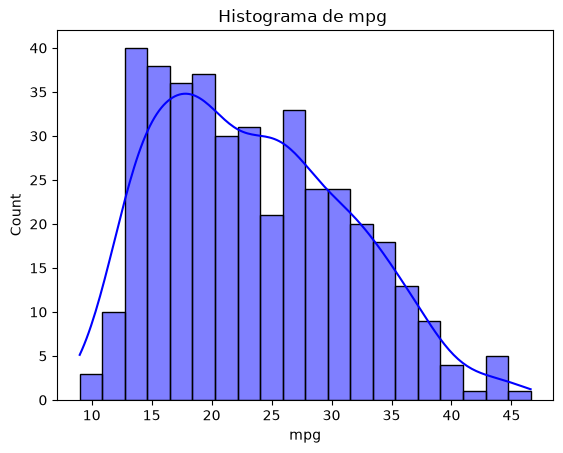

In [12]:
sns.histplot(data=df,x="mpg",bins=20,kde=True,color="b")
plt.title("Histograma de mpg ")
plt.show()

## 7. Analiza `weight` con histograma y boxplot. ¿La distribución es simétrica? ¿Hay valores 
extremos según la regla del IQR? Documenta el cálculo. 
Pista de trabajo: Calcula Q1, Q3, IQR y límites inferior/superior.

             q1      q3      iqr
weight  2223.75  3608.0  1384.25
--------------------------------------------------
Limite inferior weight    147.375
dtype: float64
Limite superior weight    5684.375
dtype: float64


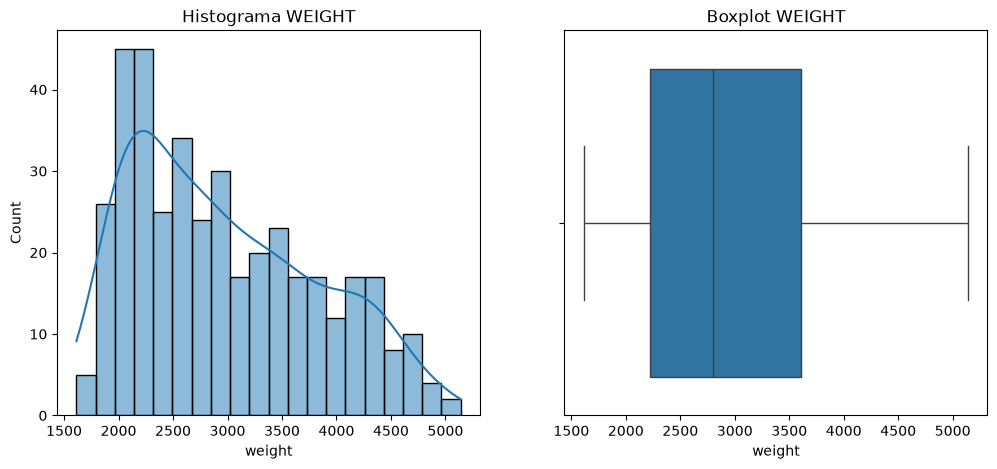

In [13]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=df,x="weight",bins=20,kde=True,ax=axes[0])
axes[0].set_title("Histograma WEIGHT")
sns.boxplot(data=df,x="weight",ax=axes[1])
axes[1].set_title("Boxplot WEIGHT")

q=df[["weight"]].quantile([0.25,0.75]).T
q.columns=["q1","q3"]
q["iqr"]=q["q3"]-q["q1"]
print(q)
print("-"*50)
lower=q["q1"] - 1.5 * q["iqr"]
print("Limite inferior",lower)
upper=q["q3"]+1.5*q["iqr"]
print("Limite superior",upper)


## 8. Detecta outliers en `horsepower` usando 1.5·IQR. Lista los vehículos identificados y 
comenta si parecen errores evidentes o automóviles de alta potencia plausibles.

In [14]:
Q1 = df["horsepower"].quantile(0.25)
Q3 = df["horsepower"].quantile(0.75)
print("Valor de q1",Q1)
print("Valor de q1",Q3)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
print("Valor maximo",upper)

outliers = df[df["horsepower"] > upper]
outliers

Valor de q1 75.0
Valor de q1 126.0
Valor maximo 202.5


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
13,14.0,8,455.0,225.0,3086,10.0,70,usa,buick estate wagon (sw)
25,10.0,8,360.0,215.0,4615,14.0,70,usa,ford f250
27,11.0,8,318.0,210.0,4382,13.5,70,usa,dodge d200
67,11.0,8,429.0,208.0,4633,11.0,72,usa,mercury marquis
94,13.0,8,440.0,215.0,4735,11.0,73,usa,chrysler new yorker brougham
95,12.0,8,455.0,225.0,4951,11.0,73,usa,buick electra 225 custom
116,16.0,8,400.0,230.0,4278,9.5,73,usa,pontiac grand prix


## 9. Explora `cylinders` y `origin` mediante frecuencias y gráficos de barras. ¿Qué categorías 
dominan el dataset? ¿Hay categorías con muy pocos casos? 
Pista de trabajo: Las categorías poco frecuentes pueden hacer inestables algunas comparaciones. 

In [15]:
df[["origin","cylinders"]]

,origin,cylinders
0,usa,8
1,usa,8
2,usa,8
3,usa,8
4,usa,8
...,...,...
393,usa,4
394,europe,4
395,usa,4
396,usa,4


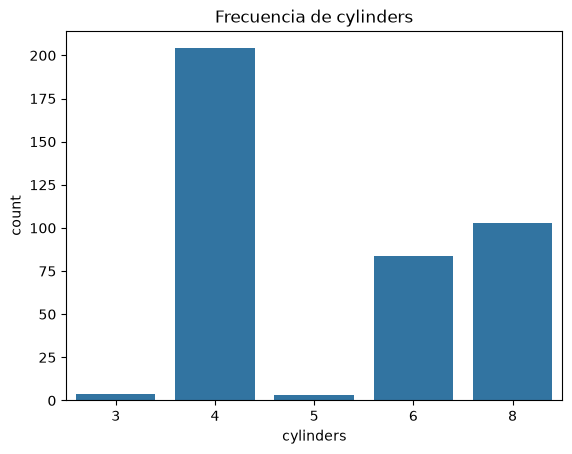

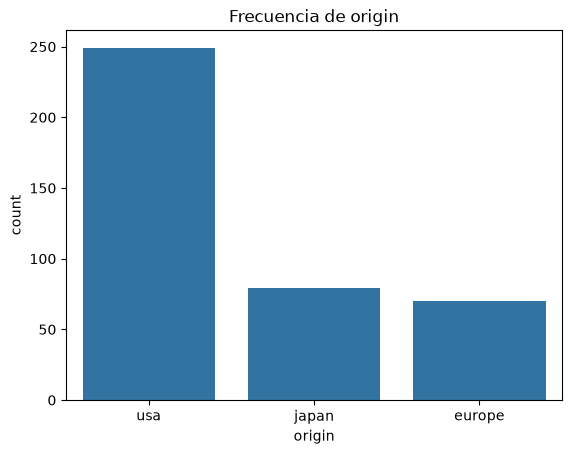

In [16]:
for col in ["cylinders","origin"]:
    sns.countplot(data=df,x=col)
    plt.title(f"Frecuencia de {col}")
    plt.show()